In [1]:
from Code import logfile_process, format_change, Tool, main
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import os

c:\Users\Jackie\anaconda3\envs\main\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
IRC_DIR = r"G:\work\Secondary_Selection\6_Potential_BO\irc_check"
SPE_METHOD = "b3lyp/6-311+g(d,p) em=gd3bj"

In [3]:
irc_log_name = "17514_18100reverse.log"
reaction_atoms = [[3, 20], [6, 19]]
split_id = 14
diene_base_energy = -528.3024675
ene_base_energy = -388.612835

In [56]:
irc_log_name = "12881_18100_00001_0002forward.log"
reaction_atoms = [[1, 20], [4, 19]]
split_id = 14
diene_base_energy = -375.0905779
ene_base_energy = -388.612835

In [4]:
new_irc_dir = IRC_DIR + "/" + irc_log_name.split(".")[0]
if not os.path.isdir(new_irc_dir):
    os.mkdir(new_irc_dir)
log = logfile_process.Logfile(IRC_DIR + "/" + irc_log_name, read_title=0)
symbol_list, position = log.symbol_list, log.running_positions
for id_, each_position in enumerate(position):
    diene_symbol_part = symbol_list[:split_id]
    ene_symbol_part = symbol_list[split_id:]
    diene_position = each_position[:split_id]
    ene_position = each_position[split_id:]
    new_diene_name = new_irc_dir + "/" + f"diene_{id_:03}.gjf"
    new_ene_name = new_irc_dir + "/" + f"ene_{id_:03}.gjf"
    new_name = new_irc_dir + "/" + f"all_{id_:03}.gjf"
    format_change.block_to_gjf(diene_symbol_part, diene_position, new_diene_name, method=SPE_METHOD)
    format_change.block_to_gjf(ene_symbol_part, ene_position, new_ene_name, method=SPE_METHOD)
    format_change.block_to_gjf(symbol_list, each_position, new_name, method=SPE_METHOD)

Can't find title
G:\work\Secondary_Selection\6_Potential_BO\irc_check/17514_18100reverse.log, can't find any engs
Error in G:\work\Secondary_Selection\6_Potential_BO\irc_check/17514_18100reverse.log


In [17]:
main.error_improve(r"G:\work\Secondary_Selection\6_Potential_BO\irc_check", "17514_18100reverse")

0it [00:00, ?it/s]


In [57]:
log = logfile_process.Logfile(IRC_DIR + "/" + irc_log_name, read_title=0)
new_irc_dir = IRC_DIR + "/" + irc_log_name.split(".")[0]
position = log.running_positions
all_CC_dist = []
all_diene_distort = []
all_ene_distort = []
all_interact = []
all_dG = []
for id_, each_position in enumerate(position):
    C_C_dist_1 = Tool.get_atoms_distance(each_position[reaction_atoms[0][0]], each_position[reaction_atoms[0][1]])
    C_C_dist_2 = Tool.get_atoms_distance(each_position[reaction_atoms[1][0]], each_position[reaction_atoms[1][1]])
    C_C_dist = (C_C_dist_1 + C_C_dist_2) / 2
    new_diene_logfile = new_irc_dir + "/" + f"diene_{id_:03}.log"
    new_ene_logfile = new_irc_dir + "/" + f"ene_{id_:03}.log"
    new_logfile = new_irc_dir + "/" + f"all_{id_:03}.log"
    diene_energy = logfile_process.Logfile(new_diene_logfile).all_engs[-1]
    ene_energy = logfile_process.Logfile(new_ene_logfile).all_engs[-1]
    all_energy = logfile_process.Logfile(new_logfile).all_engs[-1]
    diene_distort = diene_energy - diene_base_energy
    ene_distort = ene_energy - ene_base_energy
    interact = all_energy - diene_energy - ene_energy
    all_CC_dist.append(C_C_dist)
    all_diene_distort.append(diene_distort * 627.5)
    all_ene_distort.append(ene_distort * 627.5)
    all_interact.append(interact * 627.5)
    all_dG.append((all_energy - diene_base_energy - ene_base_energy) * 627.5)
new_csv_name = IRC_DIR + "/" + irc_log_name.split(".")[0] + ".csv"
pd.DataFrame({"CC_dist": all_CC_dist, "diene_distort": all_diene_distort, "ene_distort": all_ene_distort, "interact": all_interact, "dG": all_dG}).to_csv(new_csv_name, index=False)

G:\work\Secondary_Selection\6_Potential_BO\irc_check/12881_18100_00001_0002forward.log, can't find any engs
12881_18100_00001_0002forward.log 1 20 atom may ircorrect 3.3399540452627483


In [68]:
new_csv_name_1 = 'G:\\work\\Secondary_Selection\\6_Potential_BO\\irc_check/17514_18100reverse.csv'
new_csv_name_2 = 'G:\\work\\Secondary_Selection\\6_Potential_BO\\irc_check/12881_18100_00001_0002forward.csv'

In [ ]:
plt.plot(all_CC_dist, np.array(all_diene_distort) + np.array(all_ene_distort), linestyle='.', c='blue')

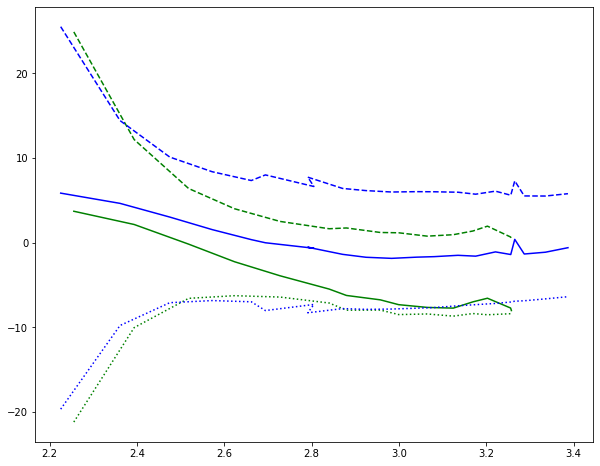

In [74]:
plt.figure(figsize=(10, 8))
for csv, color in zip([new_csv_name_1, new_csv_name_2], ["green", "blue"]):
    df = pd.read_csv(csv)
    all_diene_distort = df["diene_distort"].values
    all_ene_distort = df["ene_distort"].values
    all_interact = df["interact"].values
    all_dG = df["dG"].values
    all_CC_dist = df["CC_dist"].values

    plt.plot(all_CC_dist, np.array(all_diene_distort) + np.array(all_ene_distort), linestyle='--', c=color)
    plt.plot(all_CC_dist, all_interact, linestyle=':', c=color)
    plt.plot(all_CC_dist, all_dG, linestyle='-', c=color)
plt.show()
